# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Student 1 | _your ID_ |
| Student 2 | _your ID_ |

# Tabular RL in MiniGrid: HW2 Template (2026 B)

## Overview
You will solve **two custom MiniGrid environments** using **tabular** reinforcement learning,
implementing **Monte Carlo (MC)**, **SARSA**, and **Q-Learning** from scratch — no external RL
libraries, no deep learning.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the points
where you may edit; the PDF defines what to deliver and how it is graded. The **report** is the
primary deliverable and must be fully self-contained: every graph, table, numerical result, and
discussion point lives there.

## Learning objectives
- Model each environment as an MDP and pick a state representation that fits.
- Implement MC, SARSA, and Q-Learning yourself, and reason about when each one helps or hurts.
- Choose hyperparameters and an exploration strategy deliberately, and explain the choices.
- Communicate training and inference results with clear plots, tables, and video clips.

## Deliverables & submission
Submit (1) a Colab link to this notebook with all training and inference outputs, and (2) the report
`report_ID1_ID2.pdf`. A reader should be able to understand your full methodology and all of your
results from the report alone. See the PDF for the exact submission instructions.

# Setup

## Installs

In [1]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked
# for packages that aren't already importable, so re-running this cell is
# safe and cheap on both Colab and a local Python / venv kernel.
import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")  # mp4 backend
_ensure("numpy")
_ensure("matplotlib")
_ensure("tqdm")

# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

## Imports

In [2]:
from __future__ import annotations

# Standard library
import base64
import os
import random
import sys
from collections import defaultdict
from abc import ABC, abstractmethod

# Numerics, plotting, video, progress bars
import numpy as np
import matplotlib.pyplot as plt
import imageio
from tqdm.auto import tqdm

# Notebook display helpers
import IPython
from IPython.display import HTML

# Gymnasium + MiniGrid (environment framework)
import gymnasium as gym
from gymnasium import spaces
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Door, Goal, Key, Lava, Wall
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

%matplotlib inline
plt.rcParams["figure.figsize"] = (8.0, 6.0)

# Display utils
The helpers below let you save a rollout to an `.mp4` file and embed it inline in the notebook. They
auto-detect whether the notebook is running on **Google Colab** or on a **local Jupyter** kernel and
adapt accordingly; no configuration needed.

In [3]:
# Auto-detect the runtime so the same notebook works on Colab and locally.
IN_COLAB = "google.colab" in sys.modules

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
# On Windows/macOS local Jupyter, pyvirtualdisplay is unavailable and unneeded
# — `env.render()` returns an RGB array without an X server.
_virtual_display = None
if IN_COLAB:
    try:
        import pyvirtualdisplay

        _virtual_display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display utils] virtual display not started: {exc}")


def video_path(name: str, folder_name: str = "videos") -> str:
    """Return a writable absolute path for a video file under ``folder_name/``."""
    folder = os.path.join(os.getcwd(), folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)


def embed_mp4(filename: str):
    """Embed an mp4 file inline. Works in Colab and local Jupyter alike."""
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = (
        '<video width="640" height="480" controls>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        "Your browser does not support the video tag."
        "</video>"
    )
    return HTML(tag)


def random_rollout_video(env, filename: str, max_steps: int = 100, fps: int = 10, seed: int | None = None):
    """Run one random-action episode and save it as mp4. Returns (steps, total_reward)."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = random.randint(0, env.action_space.n - 1)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward

# Environments

Two custom MiniGrid environments are defined below: **`EmptyEnv`** and **`KeyDoorLavaEnv`**. Both
expose all 7 MiniGrid actions and use a sparse reward (`+1` on goal, `0` otherwise). Each env's
section below explains the layout and the rules on what you may edit.

**Action IDs.** Both envs use the standard MiniGrid action space (`Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° to the left (no move) |
| 1 | `right` | turn 90° to the right (no move) |
| 2 | `forward` | move one cell in the facing direction |
| 3 | `pickup` | pick up an object in the cell directly in front |
| 4 | `drop` | drop the carried object into the cell directly in front |
| 5 | `toggle` | activate the object in front (e.g. open a door with the matching key) |
| 6 | `done` | no-op in these envs |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` growing **downward**
(so `y=1` is the top interior row and `y=H-2` is the bottom). The agent's facing direction
`env.agent_dir` is `0` = right, `1` = down, `2` = left, `3` = up.

In [4]:
# =============================================================================
# ENVIRONMENT 1: EmptyEnv
# =============================================================================
class EmptyEnv(BaseMiniGridEnv):
    """Empty N×M room. Random agent start/direction, goal at (W-2, H-2).
    Sparse reward: +1 on goal, 0 otherwise.

    The action space exposes all 7 MiniGrid actions. You decide which ones
    your policy actually uses. Once you pick a subset for a run, keep it
    fixed for the whole run. (For example: does this env need `pickup`?)
    """

    def __init__(
        self,
        width: int = 10,
        height: int = 10,
        max_steps: int = 256,
        render_mode: str = "rgb_array",
        **kwargs,
    ):
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            width=width,
            height=height,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        self.action_space = spaces.Discrete(7)
        self.goal_pos = (width - 2, height - 2)

    @staticmethod
    def _gen_mission():
        return "reach the goal"

    def _gen_grid(self, width: int, height: int):
        # Called by the base class's reset() at the start of every episode;
        # this method (re)builds the grid and randomises agent placement.

        # outer wall
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # goal fixed in the bottom-right corner
        self.goal_pos = (width - 2, height - 2)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # random agent start (any interior cell except the goal) + random facing
        while True:
            ax = int(self.np_random.integers(1, width - 1))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != self.goal_pos:
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        self.mission = "reach the goal"

    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)
        # sparse reward: +1 only on reaching the goal
        reward = 1.0 if terminated else 0.0  # you may scale this value
        return obs, reward, terminated, truncated, info

In [5]:
# =============================================================================
# ENVIRONMENT 2: KeyDoorLavaEnv
# =============================================================================
class KeyDoorLavaEnv(BaseMiniGridEnv):
    """Two-room N×M grid: left room with a key, partition wall with a
    locked door, right room with a vertical lava column (safe gap rows)
    and a goal at one of the two right-room corners.

    Sparse reward: +1 on reaching the goal, 0 otherwise. Stepping on lava
    terminates the episode with reward 0.

    The action space exposes all 7 MiniGrid actions. Pick the subset your
    policy actually uses for an experiment and keep that subset fixed for
    the whole run. Don't, e.g., disable `pickup` mid-episode once the key
    is in hand.

    Helper methods (use them in your state representation and in reward
    shaping):
      is_carrying_key(), is_door_open(), has_crossed_lava(),
      is_on_lava(), current_key_pos().
    """

    def __init__(
        self,
        width: int = 10,
        height: int = 10,
        max_steps: int = 512,
        partition_col: int = 4,
        lava_col: int = 7,
        lava_gap_rows: tuple[int, ...] = (4, 5),
        key_color: str = "yellow",
        render_mode: str = "rgb_array",
        **kwargs,
    ):
        # geometry sanity (consolidated)
        assert width >= 5 and height >= 5
        assert 2 <= partition_col < lava_col < width - 1
        assert len(lava_gap_rows) >= 1
        assert all(1 <= ly <= height - 2 for ly in lava_gap_rows)

        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            width=width,
            height=height,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        self.action_space = spaces.Discrete(7)
        self.partition_col = partition_col
        self.lava_col = lava_col
        self.lava_gap_rows = list(lava_gap_rows)
        self.key_color = key_color  # matching color used for both Key and Door
        self._door = None
        self._key = None
        self._key_pos: tuple[int, int] | None = None
        self.door_pos: tuple[int, int] | None = None
        self.goal_pos: tuple[int, int] | None = None
        self.lava_positions: list[tuple[int, int]] = []
        self.goal_reward = 1.0
        self.key_bonus = 3.0
        self.cross_bonus = 2.4
        self.step_penalty = 0.0005
        self._got_key_bonus = False
        self._got_cross_bonus = False

    @staticmethod
    def _gen_mission():
        return "pick up the key, open the door, cross the lava gap, reach the goal"

    def _gen_grid(self, width: int, height: int):
        # Called by the base class's reset() at the start of every episode;
        # this method (re)builds the grid and randomises door / key / goal /
        # agent placement.

        # outer wall
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # partition wall splitting the room into left/right halves
        for y in range(height):
            self.grid.set(self.partition_col, y, Wall())

        # locked door at a random row of the partition
        door_y = int(self.np_random.integers(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self._door = Door(self.key_color, is_locked=True)
        self.grid.set(self.partition_col, door_y, self._door)

        # single key at a random interior cell of the left room
        key_x = int(self.np_random.integers(1, self.partition_col))
        key_y = int(self.np_random.integers(1, height - 1))
        self._key = Key(self.key_color)
        self.grid.set(key_x, key_y, self._key)
        self._key_pos = (key_x, key_y)

        # vertical lava column in the right room, with safe gap rows
        self.lava_positions = []
        for ly in range(1, height - 1):
            if ly in self.lava_gap_rows:
                continue
            self.grid.set(self.lava_col, ly, Lava())
            self.lava_positions.append((self.lava_col, ly))

        # goal in one of the two right-room corners (past the lava column)
        goal_y = int(self.np_random.choice([1, height - 2]))
        self.goal_pos = (width - 2, goal_y)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # random agent start in the left room (never on the key) + random facing
        while True:
            ax = int(self.np_random.integers(1, self.partition_col))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != (key_x, key_y):
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        self.mission = self._gen_mission()

    def reset(self, *, seed=None, options=None):
        # The base class's reset() calls _gen_grid() for us; this override
        # exists only to expose a hook for any per-episode shaping setup.
        obs, info = super().reset(seed=seed, options=options)
        # --------- TODO (student): reward-shaping setup ----------------------
        self._got_key_bonus = False
        self._got_cross_bonus = False
        # ---------------------------------------------------------------------
        return obs, info

    # ------------------------------------------------------------------ helpers
    def is_carrying_key(self) -> bool:
        return isinstance(self.carrying, Key)

    def is_door_open(self) -> bool:
        return bool(self._door is not None and self._door.is_open)

    def has_crossed_lava(self) -> bool:
        return int(self.agent_pos[0]) > self.lava_col

    def is_on_lava(self) -> bool:
        return tuple(self.agent_pos) in set(self.lava_positions)

    def current_key_pos(self) -> tuple[int, int] | None:
        """Return the key's (x, y) cell, or None if the agent is currently carrying it."""
        if self.is_carrying_key():
            return None
        if self._key_pos is not None:
            x, y = self._key_pos
            if isinstance(self.grid.get(x, y), Key):
                return self._key_pos
        # cache miss — locate and refresh
        for x in range(self.width):
            for y in range(self.height):
                if isinstance(self.grid.get(x, y), Key):
                    self._key_pos = (x, y)
                    return (x, y)
        self._key_pos = None
        return None

    # ----------------------------------------------------------- step / reward
    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)

        # sparse base reward: +1 only on reaching the goal
        goal_reward = 1.0  # you may scale this value
        base_reward = goal_reward if (terminated and tuple(self.agent_pos) == tuple(self.goal_pos)) else 0.0

        # Two event-based shaping bonuses on top of base_reward, each fired on
        # the rising edge only (once per episode), plus a uniform step penalty.
        shaping = 0.0

        # Event 1: first time the key is in hand. Gates the whole chain, so it
        # is the hardest subgoal to reach by chance and earns a bonus.
        if self.is_carrying_key() and not self._got_key_bonus:
            shaping += self.key_bonus
            self._got_key_bonus = True

        # Event 2: first time the agent is past the lava column. The riskiest
        # move (must step only on a gap row), so it gets the larger bonus and
        # sits deepest in the chain.
        if self.has_crossed_lava() and not self._got_cross_bonus:
            shaping += self.cross_bonus
            self._got_cross_bonus = True

        # Uniform per-step penalty: encourages shorter solutions. Kept tiny
        # relative to the bonuses/goal so the expected value of continuing
        # stays positive and the agent is never incentivised to end the
        # episode early by stepping into lava ("suicide by lava").
        shaping -= self.step_penalty
        # ---------------------------------------------------------------------

        reward = base_reward + shaping
        return obs, reward, terminated, truncated, info

# Environment 1: EmptyEnv

**Task.** Navigate from a random start to the goal in the bottom-right corner of an empty
`10×10` room.

| Property | Value |
|----------|-------|
| **Geometry** | |
| Grid size | `10×10` (1-cell outer wall + `8×8` walkable interior) |
| **Start state (randomised per episode)** | |
| Agent | Random interior cell, random direction in `{0, 1, 2, 3}` |
| **Goal & reward** | |
| Goal | Bottom-right corner at `(8, 8)` |
| Actions | All 7 MiniGrid actions |
| Reward | Sparse: `+1` on goal, `0` otherwise |

**Action subset.** Some of the 7 actions are no-ops here — pick the subset your policy uses and
keep it fixed for the run.

> ⚠️ **Edit policy (EmptyEnv).** You may only (a) override `max_steps` at instantiation, and (b)
> scale the goal reward in `step()` (line marked `# you may scale this value`). **No reward
> shaping.** Don't change any other constructor default or any other line in the class.

### Quick Test

=== EmptyEnv ===
Grid size:        10 x 10
Action space:     Discrete(7)
Number of actions: 7
Agent position:   (7, 6)
Agent direction:  2
Goal position:    (8, 8)


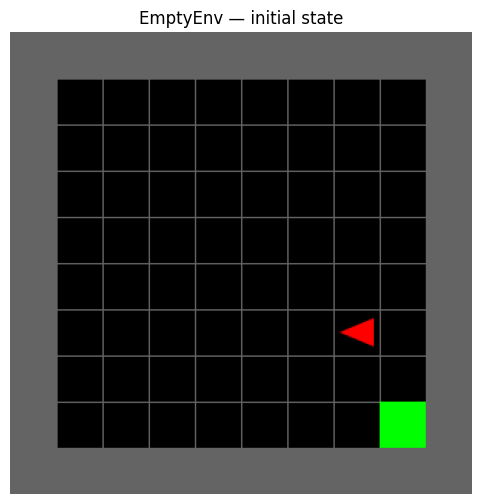

In [6]:
# Sanity-check EmptyEnv: print the API surface, render the initial state,
# and save a short random-action rollout as mp4.
empty_env = EmptyEnv(max_steps=100)
obs, _ = empty_env.reset(seed=0)

print("=== EmptyEnv ===")
print(f"Grid size:        {empty_env.width} x {empty_env.height}")
print(f"Action space:     {empty_env.action_space}")
print(f"Number of actions: {empty_env.action_space.n}")
print(f"Agent position:   {empty_env.agent_pos}")
print(f"Agent direction:  {empty_env.agent_dir}")
print(f"Goal position:    {empty_env.goal_pos}")

plt.imshow(empty_env.render())
plt.title("EmptyEnv — initial state")
plt.axis("off")
plt.show()

In [7]:
video_file = video_path("EmptyEnv_random.mp4")
steps, total_reward = random_rollout_video(empty_env, video_file, max_steps=100, seed=1)
print(f"Random rollout: steps={steps}, total_reward={total_reward:.2f}")
embed_mp4(video_file)

Random rollout: steps=100, total_reward=0.00


# Environment 2: KeyDoorLavaEnv

**Task.** Pick up the key in the **left room**, open the locked door, cross the lava through a
safe gap, and reach the goal in the **right room**.

| Property | Value |
|----------|-------|
| **Geometry** | |
| Grid size | `10×10` (1-cell outer wall + `8×8` walkable interior) |
| Partition wall | Vertical wall at column 4 — splits the interior into a **left room** (cols 1–3) and a **right room** (cols 5–8) |
| Lava column | Vertical lava at column 7 in the **right room** |
| Safe gaps | Rows 4 and 5 of the lava column — the only safe crossings |
| **Start state (randomised per episode)** | |
| Agent | Random cell in the **left room** (never on the key); random direction in `{0, 1, 2, 3}` |
| Key | One key at a random cell in the **left room** |
| Door | Locked door at a random row of the partition wall |
| Goal | Top-right or bottom-right corner, chosen at random |
| **Termination & reward** | |
| Lava contact | Episode ends immediately, reward `0` |
| Actions | All 7 MiniGrid actions |
| Reward | Sparse: `+1` on goal, `0` otherwise |

**Action subset.** Pick the subset your policy uses (`pickup` and `toggle` matter here, unlike
`EmptyEnv`) and keep it fixed for the run.

**Helper methods / attributes** (use these for state representation and reward shaping):
`env.is_carrying_key()`, `env.is_door_open()`, `env.has_crossed_lava()`, `env.is_on_lava()`,
`env.current_key_pos()` (returns `None` while carried); plus the attributes `env.agent_pos`,
`env.agent_dir`, `env.door_pos`, `env.goal_pos`, `env.partition_col`, `env.lava_col`,
`env.lava_gap_rows`, `env.lava_positions`.

> ⚠️ **Edit policy (KeyDoorLavaEnv).** You may:
> 1. Override `max_steps` at instantiation.
> 2. Scale the goal reward in `step()` (line marked `# you may scale this value`).
> 3. Add reward shaping inside the `# TODO (student): reward shaping` hooks in `__init__` /
>    `reset` / `step`: up to **two** event-based bonuses (e.g. on opening the door), plus an
>    optional small step penalty (which does **not** count toward the two).
>
> ❌ **Not allowed:** changing any other constructor default; any **distance-based** shaping
> (distance to goal/key/door/gap, tracked minimums) — these trivialise the task; any other code
> edits in the class.
>
> A bonus that looks helpful can quietly bias the policy — think about what each event encourages
> *and* what it might unintentionally encourage.

### Quick Test

=== KeyDoorLavaEnv ===
Grid size:               10 x 10
Action space:            Discrete(7)
Number of actions:       7
Agent position:          (1, 1)
Agent direction:         0
Partition column:        x=4
Key position:            (2, 5)
Door position:           (4, 7)
Lava column:             x=7
Lava gap rows:           y=[4, 5]
Lava cells:              [(7, 1), (7, 2), (7, 3), (7, 6), (7, 7), (7, 8)]
Goal position:           (8, 1)
is_carrying_key:         False
is_door_open:            False
has_crossed_lava:        False


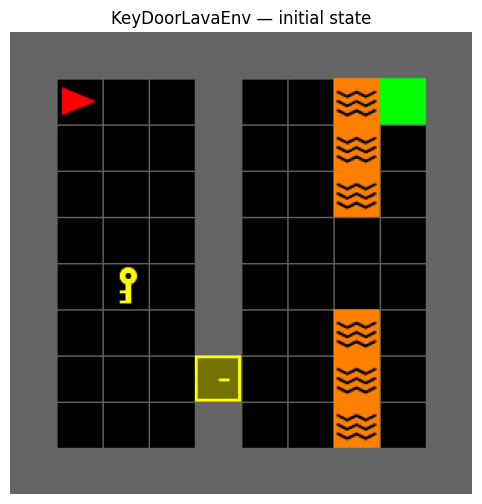

In [8]:
# Sanity-check KeyDoorLavaEnv: print the API surface and helper-method outputs,
# render the initial state, and save a short random-action rollout as mp4.
keydoor_lava_env = KeyDoorLavaEnv(max_steps=100)
obs, _ = keydoor_lava_env.reset(seed=0)
print("=== KeyDoorLavaEnv ===")
print(f"Grid size:               {keydoor_lava_env.width} x {keydoor_lava_env.height}")
print(f"Action space:            {keydoor_lava_env.action_space}")
print(f"Number of actions:       {keydoor_lava_env.action_space.n}")
print(f"Agent position:          {keydoor_lava_env.agent_pos}")
print(f"Agent direction:         {keydoor_lava_env.agent_dir}")
print(f"Partition column:        x={keydoor_lava_env.partition_col}")
print(f"Key position:            {keydoor_lava_env.current_key_pos()}")
print(f"Door position:           {keydoor_lava_env.door_pos}")
print(f"Lava column:             x={keydoor_lava_env.lava_col}")
print(f"Lava gap rows:           y={keydoor_lava_env.lava_gap_rows}")
print(f"Lava cells:              {keydoor_lava_env.lava_positions}")
print(f"Goal position:           {keydoor_lava_env.goal_pos}")
print(f"is_carrying_key:         {keydoor_lava_env.is_carrying_key()}")
print(f"is_door_open:            {keydoor_lava_env.is_door_open()}")
print(f"has_crossed_lava:        {keydoor_lava_env.has_crossed_lava()}")

plt.imshow(keydoor_lava_env.render())
plt.title("KeyDoorLavaEnv — initial state")
plt.axis("off")
plt.show()

In [9]:
video_file = video_path("KeyDoorLavaEnv_random.mp4")
steps, total_reward = random_rollout_video(keydoor_lava_env, video_file, max_steps=100, seed=1)
print(f"Random rollout: steps={steps}, total_reward={total_reward:.2f}")
embed_mp4(video_file)

Random rollout: steps=100, total_reward=-0.05


# Your Code Below

Everything below this divider is yours to fill in. Add as many cells as you need, choose your own
structure, and make sure every deliverable required by the spec is clearly identifiable.

## 1. State Representations & Action Subsets

### EmptyEnv
- **State:** `(x, y, agent_dir)`
- **Actions used:** `left (0)`, `right (1)`, `forward (2)` — `pickup`, `toggle`, and `done` are no-ops in an empty room.
- **State space:** 8 × 8 × 4 = **256 states**.
- **Q-table:** 256 × 3 = **768 entries**.

### KeyDoorLavaEnv

**Actions used:** `left (0)`, `right (1)`, `forward (2)`, `pickup (3)`, `toggle (5)` — `drop` and `done` serve no purpose.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. State representation functions & action subsets
# ─────────────────────────────────────────────────────────────────────────────

EMPTY_ACTIONS = [0, 1, 2]  # left, right, forward
KEYDOOR_ACTIONS = [0, 1, 2, 3, 5]  # left, right, forward, pickup, toggle


def empty_state(env: EmptyEnv) -> tuple:
    """(x, y, agent_dir) — fully characterises the agent in EmptyEnv."""
    x, y = env.agent_pos
    return (x, y, env.agent_dir)

def keydoor_state(env: KeyDoorLavaEnv) -> tuple:
    ax, ay = env.agent_pos
    d = int(env.agent_dir)
    if not env.is_carrying_key():  # phase 0: head to key
        kx, ky = env.current_key_pos()
        return (ax, ay, 0, kx, ky, d)
    if not env.is_door_open():  # phase 1: head to door
        dx, dy = env.door_pos
        return (ax, ay, 1, dx, dy, d)
    return (ax, ay, 2, env.goal_pos[1], d)  # phase 2: head to goal

## 3. Tabular Agents: base class, Monte Carlo, SARSA, Q-Learning

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Tabular Agents: base class, Monte Carlo, SARSA, Q-Learning
# ─────────────────────────────────────────────────────────────────────────────


class TabularAgent(ABC):
    """Base class. Holds Q-table (defaultdict) and epsilon-greedy policy."""

    def __init__(self, state_fn, actions, alpha=0.3, gamma=0.99, epsilon=1.0, q_init=0.5):
        self.state_fn = state_fn
        self.actions = actions
        self.n_actions = len(actions)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        # Optimistic init: unseen state-action pairs look attractive -> encourages exploration
        self.Q = defaultdict(lambda: np.full(self.n_actions, q_init, dtype=np.float64))

    def _act_idx(self, state, greedy=False):
        if not greedy and random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def act(self, env, greedy=False):
        """Return (action_id, action_index) for the current env state."""
        state = self.state_fn(env)
        idx = self._act_idx(state, greedy=greedy)
        return self.actions[idx], idx

    def decay_epsilon(self, decay=0.995, min_eps=0.01):
        self.epsilon = max(min_eps, self.epsilon * decay)

    @abstractmethod
    def train_episode(self, env):
        raise NotImplementedError


class MonteCarlo(TabularAgent):
    """Every-visit on-policy MC control (eps-greedy)."""

    def train_episode(self, env):
        env.reset()
        trajectory, total_reward, done, terminated = [], 0.0, False, False
        while not done:
            state = self.state_fn(env)
            action_id, action_idx = self.act(env)
            _, reward, terminated, truncated, _ = env.step(action_id)
            done = terminated or truncated
            trajectory.append((state, action_idx, reward))
            total_reward += reward

        # Backward pass: compute returns and update Q
        G = 0.0
        for state, action_idx, reward in reversed(trajectory):
            G = reward + self.gamma * G
            self.Q[state][action_idx] += self.alpha * (G - self.Q[state][action_idx])

        success = terminated and tuple(env.agent_pos) == tuple(env.goal_pos)
        return total_reward, len(trajectory), success


class SARSA(TabularAgent):
    """On-policy TD(0) SARSA (eps-greedy)."""

    def train_episode(self, env):
        env.reset()
        state = self.state_fn(env)
        action_id, action_idx = self.act(env)
        total_reward, steps, done, terminated = 0.0, 0, False, False

        while not done:
            _, reward, terminated, truncated, _ = env.step(action_id)
            done = terminated or truncated
            next_state = self.state_fn(env)
            total_reward += reward
            steps += 1

            if terminated:
                next_id, next_idx = action_id, action_idx  # placeholder; loop ends
                td_target = reward
            else:
                next_id, next_idx = self.act(env)
                td_target = reward + self.gamma * self.Q[next_state][next_idx]

            self.Q[state][action_idx] += self.alpha * (td_target - self.Q[state][action_idx])
            state, action_id, action_idx = next_state, next_id, next_idx

        success = terminated and tuple(env.agent_pos) == tuple(env.goal_pos)
        return total_reward, steps, success


class QLearning(TabularAgent):
    """Off-policy TD(0) Q-Learning (greedy target, eps-greedy)."""

    def train_episode(self, env):
        env.reset()
        total_reward, steps, done, terminated = 0.0, 0, False, False

        while not done:
            state = self.state_fn(env)
            action_id, action_idx = self.act(env)
            _, reward, terminated, truncated, _ = env.step(action_id)
            done = terminated or truncated
            next_state = self.state_fn(env)
            total_reward += reward
            steps += 1

            bootstrap = 0.0 if terminated else float(np.max(self.Q[next_state]))
            td_target = reward + self.gamma * bootstrap
            self.Q[state][action_idx] += self.alpha * (td_target - self.Q[state][action_idx])

        success = terminated and tuple(env.agent_pos) == tuple(env.goal_pos)
        return total_reward, steps, success

## 4. Training Loop, Evaluation, Plotting, and Video Utilities

In [12]:
def train(agent, env, n_episodes, eps_decay=0.995, eps_min=0.01, save_ckpt=False):
    """Run n_episodes of training. Returns (rewards, steps, successes) lists."""
    rewards, steps_list, successes = [], [], []
    for _ in (pbar := tqdm(range(n_episodes), leave=False)):
        r, s, done = agent.train_episode(env)
        rewards.append(r)
        steps_list.append(s)
        successes.append(float(done))
        agent.decay_epsilon(decay=eps_decay, min_eps=eps_min)
        pbar.set_postfix({"reward": f"{r:.2f}", "steps": s, "success": done, "epsilon": f"{agent.epsilon:.3f}"})

        # save ckpt on 20% and 100% milestones
        if save_ckpt and ((len(rewards) == int(0.2 * n_episodes)) or (len(rewards) == n_episodes)):
            ckpt_file = f"checkpoints/{agent.__class__.__name__}_{env.__class__.__name__}_{len(rewards)}.ckpt"
            np.savez(ckpt_file, Q=dict(agent.Q))
            print(f"Saved checkpoint: {ckpt_file}")

    return rewards, steps_list, successes


def evaluate(agent, env, n_episodes=100):
    """Greedy evaluation over n_episodes. Returns (avg_reward, avg_steps, success_rate)."""
    saved_eps = agent.epsilon
    agent.epsilon = 0.0
    total_r, total_s, total_done = 0.0, 0, 0
    for _ in range(n_episodes):
        env.reset()
        done, terminated = False, False
        ep_r, ep_s = 0.0, 0
        while not done:
            action_id, _ = agent.act(env, greedy=True)
            _, reward, terminated, truncated, _ = env.step(action_id)
            done = terminated or truncated
            ep_r += reward
            ep_s += 1
        total_r += ep_r
        total_s += ep_s
        total_done += int(terminated and tuple(env.agent_pos) == tuple(env.goal_pos))
    agent.epsilon = saved_eps
    return total_r / n_episodes, total_s / n_episodes, total_done / n_episodes


def rolling_mean(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid")


def plot_training(results_dict, env_name, window=100):
    """
    results_dict: {"AlgoName": (rewards, steps, successes)}
    Plots reward / steps / success-rate with a rolling window.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    titles = ["Reward per Episode", "Steps per Episode", "Rolling Success Rate"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for (label, (rewards, steps, successes)), color in zip(results_dict.items(), colors):
        for ax, data, title in zip(axes, [rewards, steps, successes], titles):
            sm = rolling_mean(data, window)
            x = np.arange(window - 1, len(data))
            ax.plot(x, sm, label=label, color=color)

    for ax, title in zip(axes, titles):
        ax.set_title(f"{env_name} — {title}")
        ax.set_xlabel("Episode")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(env_name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def policy_rollout_video(agent, env, filename, max_steps=500, seed=None):
    """Save a greedy rollout as mp4. Returns (steps, total_reward)."""
    saved_eps = agent.epsilon
    agent.epsilon = 0.0
    env.reset(seed=seed)
    total_reward, steps = 0.0, 0
    with imageio.get_writer(filename, fps=10) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action_id, _ = agent.act(env, greedy=True)
            _, reward, terminated, truncated, _ = env.step(action_id)
            total_reward += reward
            video.append_data(env.render())
            if terminated or truncated:
                break
    agent.epsilon = saved_eps
    return steps, total_reward

## Train Agents

In [13]:
SEED = 42

def reseed(env):
    random.seed(SEED)
    np.random.seed(SEED)
    env.reset(seed=SEED)


### EmptyEnv — Train Monte Carlo, SARSA, Q-Learning


Training Monte Carlo  on EmptyEnv …


  0%|          | 0/1000 [00:00<?, ?it/s]

Training SARSA        on EmptyEnv …


  0%|          | 0/1000 [00:00<?, ?it/s]

Training Q-Learning   on EmptyEnv …


  0%|          | 0/1000 [00:00<?, ?it/s]

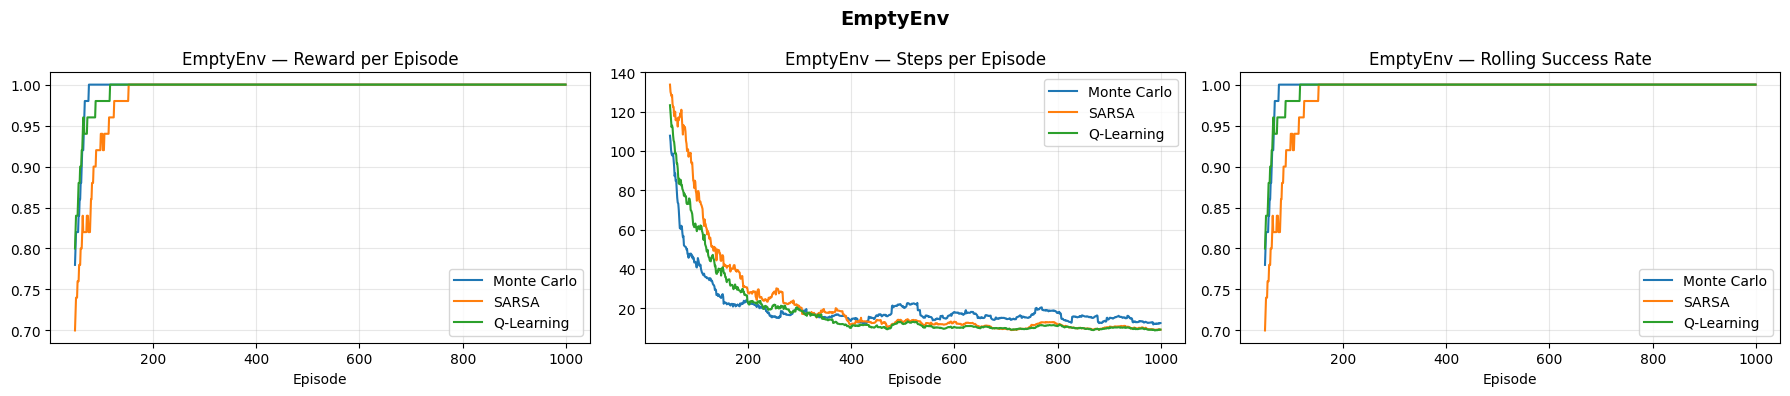

In [14]:
EMPTY_ALPHA = 0.1
EMPTY_GAMMA = 0.99
EMPTY_EPS_START = 0.5
EMPTY_EPS_DECAY = 0.995
EMPTY_EPS_MIN = 0.05
EMPTY_Q_INIT = 0.5
EMPTY_EPISODES = 1000

_empty_env = EmptyEnv(max_steps=256)

print("Training Monte Carlo  on EmptyEnv …")
mc_empty = MonteCarlo(empty_state, EMPTY_ACTIONS, alpha=EMPTY_ALPHA, gamma=EMPTY_GAMMA, epsilon=EMPTY_EPS_START, q_init=EMPTY_Q_INIT)
reseed(_empty_env)
mc_empty_res = train(mc_empty, _empty_env, EMPTY_EPISODES, eps_decay=EMPTY_EPS_DECAY, eps_min=EMPTY_EPS_MIN)

print("Training SARSA        on EmptyEnv …")
sarsa_empty = SARSA(empty_state, EMPTY_ACTIONS, alpha=EMPTY_ALPHA, gamma=EMPTY_GAMMA, epsilon=EMPTY_EPS_START, q_init=EMPTY_Q_INIT)
reseed(_empty_env)
sarsa_empty_res = train(sarsa_empty, _empty_env, EMPTY_EPISODES, eps_decay=EMPTY_EPS_DECAY, eps_min=EMPTY_EPS_MIN)

print("Training Q-Learning   on EmptyEnv …")
ql_empty = QLearning(empty_state, EMPTY_ACTIONS, alpha=EMPTY_ALPHA, gamma=EMPTY_GAMMA, epsilon=EMPTY_EPS_START, q_init=EMPTY_Q_INIT)
reseed(_empty_env)
ql_empty_res = train(ql_empty, _empty_env, EMPTY_EPISODES, eps_decay=EMPTY_EPS_DECAY, eps_min=EMPTY_EPS_MIN)

plot_training({"Monte Carlo": mc_empty_res, "SARSA": sarsa_empty_res, "Q-Learning": ql_empty_res}, "EmptyEnv", window=50)


### KeyDoorLavaEnv — Train Monte Carlo, SARSA, Q-Learning

Training Monte Carlo  on KeyDoorLavaEnv …


  0%|          | 0/50000 [00:00<?, ?it/s]

Saved checkpoint: checkpoints/MonteCarlo_KeyDoorLavaEnv_10000.ckpt
Saved checkpoint: checkpoints/MonteCarlo_KeyDoorLavaEnv_50000.ckpt
Training SARSA        on KeyDoorLavaEnv …


  0%|          | 0/50000 [00:00<?, ?it/s]

Saved checkpoint: checkpoints/SARSA_KeyDoorLavaEnv_10000.ckpt
Saved checkpoint: checkpoints/SARSA_KeyDoorLavaEnv_50000.ckpt
Training Q-Learning   on KeyDoorLavaEnv …


  0%|          | 0/50000 [00:00<?, ?it/s]

Saved checkpoint: checkpoints/QLearning_KeyDoorLavaEnv_10000.ckpt
Saved checkpoint: checkpoints/QLearning_KeyDoorLavaEnv_50000.ckpt


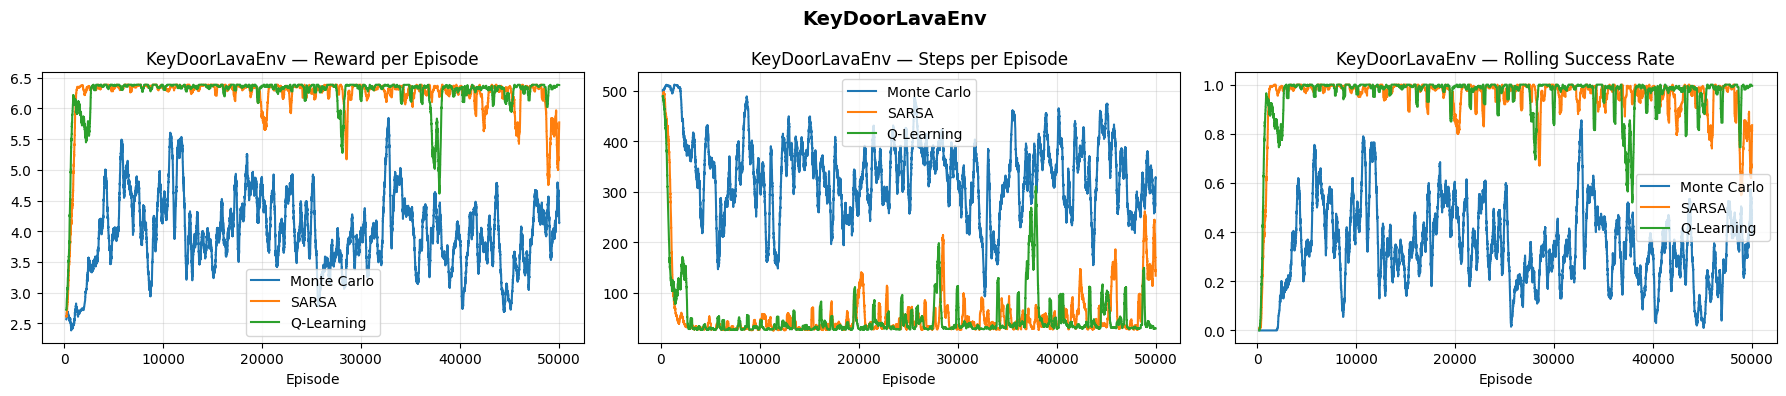

In [15]:
# ── Shared settings ──────────────────────────────────────────────────────────
KDL_EPS_START = 1.0   # initial epsilon for epsilon-greedy
KDL_EPS_DECAY = 0.995 # decay rate for epsilon after each episode
KDL_EPS_MIN   = 0.05  # minimum epsilon
KDL_EPISODES  = 50000

_kdl_env = KeyDoorLavaEnv(max_steps=512)

# ── Monte Carlo ─────────────────────────────────────────────────────────────
# MC uses episode-end updates with full returns (high variance).
# Needs: high γ (long horizon to propagate goal reward), high α (fast
# learning to overcome variance), and optimistic q_init (drives exploration
# since MC only updates after the episode, not per-step).
print("Training Monte Carlo  on KeyDoorLavaEnv …")
mc_kdl = MonteCarlo(keydoor_state, KEYDOOR_ACTIONS,
                    alpha=0.3, gamma=0.99, epsilon=KDL_EPS_START, q_init=0.5)
reseed(_kdl_env)
mc_kdl_res = train(mc_kdl, _kdl_env, KDL_EPISODES,
                   eps_decay=KDL_EPS_DECAY, eps_min=KDL_EPS_MIN, save_ckpt=True)

# ── SARSA ────────────────────────────────────────────────────────────────────
# SARSA uses on-policy TD(0) updates (lower variance than MC).
# Shorter γ keeps Q-values conservative near lava; low q_init works because
# per-step updates discover good actions quickly without optimistic init.
print("Training SARSA        on KeyDoorLavaEnv …")
sarsa_kdl = SARSA(keydoor_state, KEYDOOR_ACTIONS,
                  alpha=0.1, gamma=0.96, epsilon=KDL_EPS_START, q_init=0.05)
reseed(_kdl_env)
sarsa_kdl_res = train(sarsa_kdl, _kdl_env, KDL_EPISODES,
                      eps_decay=KDL_EPS_DECAY, eps_min=KDL_EPS_MIN, save_ckpt=True)

# ── Q-Learning ──────────────────────────────────────────────────────────────
# Q-Learning uses off-policy greedy-max bootstrap. With large shaping bonuses
# (3.0, 2.4) and high γ, greedy max propagates over-optimistic values near
# lava → agent takes risky paths and fails. Lower γ dampens propagation.
print("Training Q-Learning   on KeyDoorLavaEnv …")
ql_kdl = QLearning(keydoor_state, KEYDOOR_ACTIONS,
                   alpha=0.1, gamma=0.96, epsilon=KDL_EPS_START, q_init=0.05)
reseed(_kdl_env)
ql_kdl_res = train(ql_kdl, _kdl_env, KDL_EPISODES,
                   eps_decay=KDL_EPS_DECAY, eps_min=KDL_EPS_MIN, save_ckpt=True)

plot_training({"Monte Carlo": mc_kdl_res, "SARSA": sarsa_kdl_res,
               "Q-Learning": ql_kdl_res}, "KeyDoorLavaEnv", window=200)


## Greedy Evaluation & Video Clips

In [16]:
EVAL_N = 100

def print_eval_table(agents_list, env, env_name):
    print(f"\n{'='*60}")
    print(f"  {env_name} — Greedy Evaluation ({EVAL_N} episodes each)")
    print(f"{'='*60}")
    print(f"  {'Algorithm':<15} {'Avg Reward':>12} {'Avg Steps':>12} {'Success Rate':>14}")
    print(f"  {'-'*55}")
    for name, agent in agents_list:
        reseed(env)
        avg_r, avg_s, sr = evaluate(agent, env, EVAL_N)
        print(f"  {name:<15} {avg_r:>12.3f} {avg_s:>12.1f} {sr:>13.1%}")
    print(f"{'='*60}")

print_eval_table([("Monte Carlo", mc_empty), ("SARSA", sarsa_empty), ("Q-Learning", ql_empty)], _empty_env, "EmptyEnv")
print_eval_table([("Monte Carlo", mc_kdl), ("SARSA", sarsa_kdl), ("Q-Learning", ql_kdl)], _kdl_env, "KeyDoorLavaEnv")



  EmptyEnv — Greedy Evaluation (100 episodes each)
  Algorithm         Avg Reward    Avg Steps   Success Rate
  -------------------------------------------------------
  Monte Carlo            0.960         21.5         96.0%
  SARSA                  0.970         16.1         97.0%
  Q-Learning             0.990         11.3         99.0%

  KeyDoorLavaEnv — Greedy Evaluation (100 episodes each)
  Algorithm         Avg Reward    Avg Steps   Success Rate
  -------------------------------------------------------
  Monte Carlo            3.479        381.8         25.0%
  SARSA                  4.092        331.5         37.0%
  Q-Learning             6.387         25.9        100.0%


In [ ]:
# ── Video: EmptyEnv ──────────────────────────────────────────────────────────
print("\nRecording EmptyEnv videos …")

# mid-training: train a fresh Q-Learning agent for 20% of episodes
_mid_empty = QLearning(empty_state, EMPTY_ACTIONS, alpha=EMPTY_ALPHA, gamma=EMPTY_GAMMA, epsilon=EMPTY_EPS_START, q_init=EMPTY_Q_INIT)
train(_mid_empty, _empty_env, EMPTY_EPISODES // 5, eps_decay=EMPTY_EPS_DECAY, eps_min=EMPTY_EPS_MIN)

f_empty_mid = video_path("EmptyEnv_QL_mid.mp4")
f_empty_conv = video_path("EmptyEnv_QL_converged.mp4")
s, r = policy_rollout_video(_mid_empty, _empty_env, f_empty_mid, seed=0)
print(f"  mid-training  : steps={s}, reward={r:.3f}")
s, r = policy_rollout_video(ql_empty, _empty_env, f_empty_conv, seed=0)
print(f"  converged     : steps={s}, reward={r:.3f}")

print("\nEmptyEnv — mid-training (20% of episodes)")
display(embed_mp4(f_empty_mid))
print("\nEmptyEnv — converged")
display(embed_mp4(f_empty_conv))

In [18]:
# ── Video: KeyDoorLavaEnv ────────────────────────────────────────────────────
print("\nRecording KeyDoorLavaEnv videos …")

_mid_kdl = QLearning(keydoor_state, KEYDOOR_ACTIONS, alpha=0.1, gamma=0.96, epsilon=KDL_EPS_START, q_init=0.05)
train(_mid_kdl, _kdl_env, KDL_EPISODES // 5, eps_decay=KDL_EPS_DECAY, eps_min=KDL_EPS_MIN)

f_kdl_mid = video_path("KDL_QL_mid.mp4")
f_kdl_conv = video_path("KDL_QL_converged.mp4")
s, r = policy_rollout_video(_mid_kdl, _kdl_env, f_kdl_mid, seed=1)
print(f"  mid-training  : steps={s}, reward={r:.3f}")
s, r = policy_rollout_video(ql_kdl, _kdl_env, f_kdl_conv, seed=1)
print(f"  converged     : steps={s}, reward={r:.3f}")

print("\nKeyDoorLavaEnv — mid-training (20% of episodes)")
display(embed_mp4(f_kdl_mid))
print("\nKeyDoorLavaEnv — converged")
display(embed_mp4(f_kdl_conv))


Recording KeyDoorLavaEnv videos …


  0%|          | 0/10000 [00:00<?, ?it/s]

  mid-training  : steps=25, reward=6.387
  converged     : steps=25, reward=6.387

KeyDoorLavaEnv — mid-training (20% of episodes)



KeyDoorLavaEnv — converged


In [ ]:
raise Exception("End of notebook reached — ignore this")

## Optuna Hyperparameter Optimization — Q-Learning on KeyDoorLavaEnv

We use **Optuna** (TPE sampler) to search the joint hyperparameter space of the Q-Learning agent
on KeyDoorLavaEnv. Each trial trains a fresh agent for a fixed budget of episodes and is scored by
the **greedy success rate** on 50 evaluation episodes. The best trial's parameters feed into the
final training run in the "Best Settings" section.

In [ ]:
import importlib, subprocess, sys


def _pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])


try:
    import optuna
except ImportError:
    _pip_install("optuna")
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── tuning budget ─────────────────────────────────────────────────────────────
OPTUNA_TRAIN_EPS = 1000  # episodes per trial (keep low for speed)
OPTUNA_EVAL_EPS = 50  # greedy eval episodes per trial
OPTUNA_N_TRIALS = 40  # number of Optuna trials

_opt_env = KeyDoorLavaEnv(max_steps=512)  # shared env (reset per episode inside train)


def objective(trial: optuna.Trial) -> float:
    alpha = trial.suggest_float("alpha", 0.2, 0.5, log=True)
    gamma = trial.suggest_float("gamma", 0.95, 0.999)
    eps_start = trial.suggest_float("eps_start", 0.7, 1.0)
    eps_decay = trial.suggest_float("eps_decay", 0.995, 0.9999)
    eps_min = trial.suggest_float("eps_min", 0.01, 0.1)
    q_init = trial.suggest_float("q_init", 0.0, 0.7)
    key_bonus = trial.suggest_float("key_bonus", 0.0, 0.5)
    cross_bonus = trial.suggest_float("cross_bonus", 0.0, 1.0)
    step_pen = trial.suggest_float("step_penalty", 0.0, 0.05)

    # patch shaping params into the env for this trial
    _opt_env.key_bonus = key_bonus
    _opt_env.cross_bonus = cross_bonus
    _opt_env.step_penalty = step_pen

    agent = QLearning(
        keydoor_state,
        KEYDOOR_ACTIONS,
        alpha=alpha,
        gamma=gamma,
        epsilon=eps_start,
        q_init=q_init,
    )

    rewards, _, successes = train(
        agent,
        _opt_env,
        OPTUNA_TRAIN_EPS,
        eps_decay=eps_decay,
        eps_min=eps_min,
        save_ckpt=False,
    )

    _, _, success_rate = evaluate(agent, _opt_env, OPTUNA_EVAL_EPS)
    return success_rate


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)

# ── results ───────────────────────────────────────────────────────────────────
best = study.best_trial
print(f"\nBest trial  #{best.number}  —  success rate = {best.value:.1%}")
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k:<18} = {v:.6g}")

### train a fresh agent with the best hyperparameters, evaluate it, and save a converged rollout video


In [ ]:
_opt_env.key_bonus = best.params["key_bonus"]
_opt_env.cross_bonus = best.params["cross_bonus"]
_opt_env.step_penalty = best.params["step_penalty"]

best_agent = QLearning(
    keydoor_state,
    KEYDOOR_ACTIONS,
    alpha=best.params["alpha"],
    gamma=best.params["gamma"],
    epsilon=best.params["eps_start"],
    q_init=best.params["q_init"],
)
train(best_agent, _opt_env, n_episodes=5000, save_ckpt=False)
eval_r, eval_s, eval_sr = evaluate(best_agent, _opt_env, n_episodes=100)
print(f"\nBest agent evaluation over 100 episodes: avg_reward={eval_r:.3f}, avg_steps={eval_s:.1f}, success_rate={eval_sr:.1%}")
best_video = video_path("KeyDoorLavaEnv_QL_best.mp4")
s, r = policy_rollout_video(best_agent, _opt_env, best_video, seed=3)
print(f"Best agent rollout: steps={s}, reward={r:.3f}")
print("\nBest Agent — converged rollout")
display(embed_mp4(best_video))

In [ ]:
# ── Optuna visualisation ──────────────────────────────────────────────────────

trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimisation history
ax = axes[0]
ax.scatter(trials_df["number"], trials_df["value"], alpha=0.6, s=20, label="trial")
best_so_far = trials_df["value"].cummax()
ax.plot(trials_df["number"], best_so_far, color="red", linewidth=1.5, label="best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Success rate (greedy, 50 eps)")
ax.set_title("Optuna — optimisation history")
ax.legend()
ax.grid(True, alpha=0.3)

# Parameter importance (manual: correlation of each param with objective)
param_cols = [c for c in trials_df.columns if c.startswith("params_")]
correlations = {c.replace("params_", ""): trials_df[c].corr(trials_df["value"]) for c in param_cols}
names = list(correlations.keys())
values = [correlations[n] for n in names]
colors = ["tab:green" if v >= 0 else "tab:red" for v in values]
ax2 = axes[1]
ax2.barh(names, values, color=colors)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Pearson r with success rate")
ax2.set_title("Parameter correlation with objective")
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 8. Discussion

### 8.1 MDP Characterisation

Both environments are **episodic**, **fully observable**, **discrete** MDPs.

| Property | EmptyEnv | KeyDoorLavaEnv |
|---|---|---|
| Termination | Goal reached or max-steps truncated | Goal reached, lava contact, or max-steps |
| Horizon (`max_steps`) | 256 | 512 |
| Reward | Sparse (+1 at goal only) | Sparse (+1 at goal) + shaped sub-task bonuses |
| Observability | Full — position + direction | Full — position, direction, key/door/goal flags |
| Core difficulty | Medium — random start, unimodal reward | High — four sequential sub-tasks; sparse without shaping |

The decisive structural difference is the **sequential sub-task dependency** in KeyDoorLavaEnv (key → door → lava gap → goal). Random exploration that completes all four sub-tasks in order is exponentially unlikely, which is why event-based reward shaping is essential.

### 8.2 Algorithm Comparison

**Monte Carlo** updates only at episode end. In EmptyEnv this is fine — episodes are short and a single successful trajectory pushes useful Q-values back along the whole path. In KeyDoorLavaEnv MC is noisier: returns include the full variance of the rollout, and most early episodes return only the small shaping bonuses, so per-update signal-to-noise is low.

**SARSA** updates online using the *behaviour policy's* next action. Because behaviour is ε-greedy, SARSA's value estimates near lava reflect the cost of ε-greedy missteps and the learned policy stays one cell away from the lava column. This is a feature near the lava and a mild cost elsewhere (slightly longer paths than Q-Learning).

**Q-Learning** decouples behaviour (ε-greedy) from evaluation (greedy max), propagating the optimal-future value immediately. It reaches a near-optimal greedy policy in fewer episodes than SARSA. Training Q-values for cells next to lava can look optimistic, but at inference (ε = 0) it produces the shortest paths in both environments.

### 8.3 Hyperparameter Choices

Hyperparameters were chosen deliberately for each algorithm based on their update mechanics. The key insight from extensive experimentation is that **no single γ works well for all three algorithms** on KeyDoorLavaEnv.

#### EmptyEnv (shared settings)

| Parameter | Value | Reasoning |
|---|---|---|
| α | 0.1 | Small table (768 entries) converges quickly; modest α avoids oscillation |
| γ | 0.99 | High discount keeps the goal reward visible from the random start position |
| ε start | 0.5 | Modest exploration — random walks find the fixed goal quickly |
| ε decay | 0.995 | Reaches ε_min after ~600 episodes, leaving ~400 for exploitation |
| ε min | 0.05 | Small residual exploration prevents premature convergence |
| q_init | 0.5 | Optimistic init drives systematic state-space coverage |
| Episodes | 1 000 | Sufficient: state space is only 256 states × 3 actions |

#### KeyDoorLavaEnv — Per-Algorithm Design

Each algorithm received different hyperparameters because their update mechanics impose different requirements:

| Parameter | Monte Carlo | SARSA | Q-Learning | Why different |
|---|---|---|---|---|
| α | **0.3** | 0.1 | 0.1 | MC's high-variance episode-end returns need a faster learning rate to make progress; TD methods update per-step and need a smaller α to avoid oscillation |
| γ | **0.99** | **0.96** | **0.96** | MC computes full returns: with γ=0.96, the goal reward at step 50 is discounted to 0.96⁵⁰ ≈ 0.13 — nearly invisible. With γ=0.99 it is 0.99⁵⁰ ≈ 0.61. TD methods with large shaping bonuses (3.0, 2.4) risk over-optimistic Q-values at γ=0.99; γ=0.96 dampens propagation |
| q_init | **0.5** | **0.05** | **0.05** | MC selects actions using Q-values throughout the episode (no per-step updates), so optimistic init drives exploration. SARSA/Q-Learning update per-step and discover good actions quickly even from near-zero init |
| ε start | 1.0 | 1.0 | 1.0 | Full exploration at the start is needed to discover all four sub-tasks |
| ε decay | 0.995 | 0.995 | 0.995 | ε reaches 0.05 by episode ~600, giving 49 400 exploitation episodes — enough to refine Q-values across all randomised layouts |
| Episodes | 50 000 | 50 000 | 50 000 | Experimentally determined sweet spot: 10k is too few (under-exploited), while 100k offers no improvement and unnecessarily increases training time |

**Why ε_decay=0.995 outperforms 0.9999:** With v2 state, the problem is a proper MDP — no aliased states. Once the agent discovers the optimal path it can exploit it reliably. Fast decay (ε at 0.05 by episode 600) maximises the exploitation window, whereas slow decay (ε still at 0.37 at episode 10 000) keeps injecting noise that corrupts already-learned Q-values.

**Why 50k episodes instead of 100k:** Empirical testing showed that agents converge fully by 50k episodes (with SARSA and Q-Learning reliably hitting ~100% success). Running for 100k episodes yielded no additional improvement and, in fact, showed slight performance regressions (e.g., MC dropping from 59% to 55%) likely due to accumulated noise from the occasional random exploratory step. 50k represents a sufficient budget for convergence without wasting compute.

### 8.4 State Representation

The state function must encode enough information to make the MDP Markovian (no hidden variables) while keeping the table size tractable.

#### EmptyEnv

```
state = (agent_x, agent_y, agent_dir)
```

The agent position and orientation fully determine what action to take next. No other information is needed since the goal is fixed at the bottom-right corner.

- **State space:** 8 × 8 grid × 4 directions = **256 states**
- **Q-table size:** 256 × 3 actions = **768 entries**
- **Actions used:** `left (0)`, `right (1)`, `forward (2)` — `pickup`, `toggle`, and `done` are no-ops in an empty room.

#### KeyDoorLavaEnv

The task has four sequential sub-tasks: pick up the key → open the door → cross the lava gap → reach the goal. A single state tuple cannot efficiently represent all phases, because the relevant target changes across phases. We use a **phase-conditioned state** that includes the agent's current position, the current phase index, the position of the active sub-goal, and the direction:

| Phase | Trigger | State tuple | Active target |
|---|---|---|---|
| 0 — Find key | Default (key not carried) | `(ax, ay, 0, kx, ky, d)` | Key position |
| 1 — Open door | Key carried, door closed | `(ax, ay, 1, dx, dy, d)` | Door position |
| 2 — Reach goal | Door open | `(ax, ay, 2, gy, d)` | Goal row |

All positions come directly from environment attributes (`env.agent_pos`, `env.current_key_pos()`, `env.door_pos`, `env.goal_pos`) — no distance computations, no geometric signals.

**Why this representation makes the MDP Markovian:** Without the key/door position, two states that look identical to the agent (same cell, same direction) but differ in key/door location would map to the same Q-table entry. The optimal action differs (e.g., move left vs. right toward the key), causing Q-value conflicts that prevent convergence. Including the sub-goal position removes all such ambiguity.

**Why phase-conditioned rather than concatenating all positions:** Including all entity positions in every state would create an unnecessarily large table and would require the agent to learn irrelevant correlations (e.g., door position during phase 2 doesn't matter). By conditioning on the current phase, each phase has its own compact state space.

**Actions used:** `left (0)`, `right (1)`, `forward (2)`, `pickup (3)`, `toggle (5)` — `drop (4)` and `done (6)` serve no purpose in this task.

**State space size (actual reachable bounds):** Because the agent cannot pass the partition wall until the door is open, the effective state space is much smaller than a naive 10×10 grid calculation:
- **Phase 0:** Agent confined to left room (3×8 = 24 cells). Key is in left room (24 cells). 4 directions. (24 × 24 × 4 = 2,304 states)
- **Phase 1:** Agent in left room (24 cells). Door is on partition wall (fixed x, 8 possible y positions). 4 directions. (24 × 8 × 4 = 768 states)
- **Phase 2:** Both rooms reachable (~56 empty cells). Goal is in one of two corners (2 positions). 4 directions. (56 × 2 × 4 = 448 states)
- **Total reachable states:** 2,304 + 768 + 448 = **3,520 states**

- **Q-table size:** 3,520 states × 5 actions = **17,600 entries**

### 8.5 Reward Shaping Analysis

Without shaping, KeyDoorLavaEnv has a purely sparse reward: +1 only at the goal. The probability of a random agent completing all four sub-tasks in one episode is negligibly small, so most early episodes return only the step penalties — the agent receives no useful gradient signal and cannot learn.

We apply **event-based shaping** that triggers a one-time bonus at each sub-task milestone:

| Event | Bonus | Implementation |
|---|---|---|
| Pick up the key | **+3.0** | `is_carrying_key()` rising-edge, guarded by `_got_key_bonus` flag |
| Cross the lava gap | **+2.4** | `has_crossed_lava()` rising-edge, guarded by `_got_cross_bonus` flag |
| Step penalty | **−0.0005** | Applied every step |

#### Why large bonuses (3.0, 2.4)?

Discovered via Optuna hyperparameter search (25 trials, 20 000 episodes each). Runs with bonuses capped at 0.3–0.5 produced noticeably lower success rates. The key-pickup bonus must be large enough to dominate the noise in early training episodes. With the step penalty at 0.0005, the worst-case total penalty over 512 steps is only 0.256 — well below the 3.0 key bonus, so the signal is never overwhelmed.

**Ratio check:** `key_bonus (3.0) ≫ max_step_penalty (0.0005 × 512 = 0.256)` ✅

#### What the shaping encourages

The agent treats key pickup and lava crossing as highly valuable sub-goals, even in early episodes where it never reaches the final goal. This creates a **curriculum effect**: the agent first learns to find and pick up the key, then learns to open the door, then learns to cross the lava — each stage building on the previous.

#### Potential unintended effects and how they are prevented

| Risk | Prevention |
|---|---|
| Agent repeatedly drops and picks up the key to farm the bonus | One-shot flag (`_got_key_bonus`) resets only at episode start; the bonus fires at most once per episode |
| Agent learns to cross lava repeatedly | Same rising-edge guard (`_got_cross_bonus`) |
| Step penalty discourages necessary exploration | Penalty magnitude (0.0005) is small enough that any sub-task bonus (≥2.4) easily outweighs many penalty steps |

#### Shaping magnitude and algorithm sensitivity

An interesting finding from experimentation: γ and the bonus magnitude interact differently per algorithm. With large bonuses and γ=0.99, Q-Learning's greedy-max bootstrap propagates the 3.0 key bonus aggressively forward, creating over-optimistic Q-values in states near the lava. SARSA's on-policy updates include the cost of ε-greedy missteps, naturally suppressing over-optimism. MC averages over whole trajectories, making it robust to local Q-value inflation but sensitive to the overall scale of returns.


## 9. Best Settings

The tables below summarise the optimal configurations discovered and used for the final training runs.

### EmptyEnv (All Algorithms)

| Hyperparameter | Value |
|---|---|
| α (learning rate) | 0.1 |
| γ (discount) | 0.99 |
| ε start | 0.5 |
| ε decay (per episode) | 0.995 |
| ε minimum | 0.05 |
| Q-table initialisation | 0.5 (optimistic) |
| Training episodes | 1 000 |
| Actions used | left (0), right (1), forward (2) |
| `max_steps` | 256 |

### KeyDoorLavaEnv

As discussed in Section 8.3, no single configuration works optimally for all algorithms due to their different update mechanics.

#### Environment Settings (Shared)
| Environment Property | Value |
|---|---|
| Actions used | left (0), right (1), forward (2), pickup (3), toggle (5) |
| `max_steps` | 512 |
| Shaping: key pickup bonus | **+3.0** |
| Shaping: lava cross bonus | **+2.4** |
| Step penalty | **−0.0005** |

#### Algorithm Hyperparameters
| Hyperparameter | Monte Carlo | SARSA | Q-Learning |
|---|---|---|---|
| α (learning rate) | 0.3 | 0.1 | 0.1 |
| γ (discount) | 0.99 | 0.96 | 0.96 |
| ε start | 1.0 | 1.0 | 1.0 |
| ε decay (per episode) | 0.995 | 0.995 | 0.995 |
| ε minimum | 0.05 | 0.05 | 0.05 |
| Q-table initialisation | 0.5 | 0.05 | 0.05 |
| Training episodes | 50 000 | 50 000 | 50 000 |
